<!-- DATA PROVIDER INSTRUCTIONS

1. Provide the name of your dataset, replacing the bracketed placeholder text.
2. Update the Registry of Open Data landing page URL, by replacing the bracketed placeholder text. The [REGISTRY_YAML_NAME] will correspond to the name of the YAML document in your pull request to the Registry of Open Data on Github, minus the .yaml file extension.
3. Remove these comment blocks when you have completed each section.

DATA PROVIDER INSTRUCTIONS -->

# Get to Know a Dataset: [ESO137-006]

This notebook serves as a guided tour of the [[ESO137-006]](https://registry.opendata.aws/[REGISTRY_YAML_NAME]) dataset. More usage examples, tutorials, and documentation for this dataset and others can be found at the [Registry of Open Data on AWS](https://registry.opendata.aws/).

In [2]:
# Location of the S3 bucket for this dataset
bucket = "ratt-public-data"

<!-- DATA PROVIDER INSTRUCTIONS

The goal of this section is to orient users to the structure of your dataset. 

1. How are key prefixes and objects organized in your S3 bucket?
2. What kinds of filetypes are represented in your dataset?
3. Explain with text what users are expected to encounter, and then demonstrate with code the organizational framework you applied when creating your dataset.
4. The responses to each question section are meant to be expanded or replaced as dictated by your dataset

DATA PROVIDER INSTRUCTIONS 

### Q: How have you organized your dataset? Help us understand the key prefix structure of your S3 bucket.

EXAMPLE - REPLACE
-->

### The ESO137-006 Dataset

At the top level of our S3 bucket, we have a single key prefix "ESO137" that in turn contains:

 1. the "ms1_primary.zarr" single key prefix containing Measurement Set v2 data stored in a Zarr hierarchy.
 2. the "ms1_target.zarr" single key prefix containing Measurement Set v2 data stored in a Zarr hierarchy.
 3. the "ms2_target.zarr" single key prefix containing Measurement Set v2 data stored in a Zarr hierarchy.
 
 Full documentation for this dataset can be found at: https://www.aanda.org/articles/aa/abs/2020/04/aa37800-20/aa37800-20.html.



In [3]:
# CODING GUIDELINES FOR DATA PROVIDER
#
# General notebook coding guidelines:
# 1. Assume that your reader understands the basics of Jupyter Notebooks, Python, and their Python environment.
#    The focus of this tutorial is on your dataset.
# 2. For library requirements, list the required libraries in a comment block in "requirements.txt" format
#    (https://pip.pypa.io/en/stable/reference/requirements-file-format/)
# 3. Demonstrate importing libraries with the assumption that the user has correctly installed the required
#    libraries.
# 4. List and load all library dependencies once, at this point of the notebook, unless a complicated dependency
#    set makes it unweildy.
# 5. Remember, the goal of this tutorial is a 101-level introduction to your dataset using common tools and libraries.
#    Examples using specialized environments and deep-diving methods are better suited to follow-up tutorials.
#
# CODING GUIDELINES FOR DATA PROVIDER

First we will import the Python libraries required throughout this notebook.


In [4]:
# This notebook requires the following additional libraries
# (please install using the preferred method for your environment, e.g. pip, conda):
#
# dask-ms[s3,zarr] > 0.2.30
# dask[dataframe]>=2026.3.0
# datashader >= 0.19.0
# pillow >= 12.2.0
# xarray >= 2026.4.0

# Import the libraries required for this notebook
# Built-ins
# Installed libraries
from dask.diagnostics import ProgressBar
import dask.array as da
from daskms import xds_from_storage_ms
import numpy as np
import xarray

import datashader
import datashader.transfer_functions as transfer_functions


Next, we will define the location of our zarr dataset containing the ESO137-006 data.


In [5]:
# Location of the ESO137 Zarr visibility dataset
url = f"s3://{bucket}/ESO137/ms1_target.zarr"



### Description of Data Formats and Contents

Our dataset is structured as Hierarchical [Zarr](https://zarr.dev/) Groups, each exposed as an [Xarray](https://xarray.dev/) dataset.  Each dataset contains a MeerKAT telescope *scan* where data representing the correlated electronic voltages (visibilities) are recorded at multiple timesteps and frequencies, between antenna pairs (baselines).

Our dataset used this format because [Zarr](https://zarr.dev/):
 - is a chunked storage format suitable for storing large quantities of data on both Cloud Object Stores and Posix File Systems.
 - integrates with both [NumPy](https://numpy.org/) and [Xarray](https:/xarray.dev) to provides a convenient interface for working with the underlying data.
 - handles various NumPy data types well (coordinates, timestamps, visibility data).
 - is easily processed by most programming languages.

These Zarr groups primarily contain electronic voltage data (DATA and CORRECTED_DATA), their associated weights (WEIGHT_SPECTRUM) and a mask (FLAG) indicating bad or missing data. Secondary data includes antenna coordinate positions, names and offsets as well as directional information on the field and source under observation. The data in these groups is more fully document in the [Measurement Set v2.0](https://casa.nrao.edu/Memos/229.html) specification.

Zarr is well supported by Python through its built in 'zarr-python' library. Packages such as Pandas and Polars can be used to work with JSON as well.




### Viewing the dataset with xarray and inspecting the structure with dask

Let us load some visibility data found in `s3://ratt-public-data/ESO137/ms1_target.zarr`. This describes the visibilities


In [6]:

# Load xarray dataset metadata from the remote zarr dataset
# via dask-ms [dask-ms](https://dask-ms.readthedocs.io/en/latest/).
datasets = xds_from_storage_ms(url)

for ds in datasets:
  print(ds)

<xarray.Dataset> Size: 460GB
Dimensions:          (row: 850950, chan: 4096, corr: 4, uvw: 3)
Dimensions without coordinates: row, chan, corr, uvw
Data variables: (12/22)
    ANTENNA1         (row) int32 3MB dask.array<chunksize=(50000,), meta=np.ndarray>
    ANTENNA2         (row) int32 3MB dask.array<chunksize=(50000,), meta=np.ndarray>
    ARRAY_ID         (row) int32 3MB dask.array<chunksize=(50000,), meta=np.ndarray>
    CORRECTED_DATA   (row, chan, corr) complex64 112GB dask.array<chunksize=(50000, 128, 4), meta=np.ndarray>
    DATA             (row, chan, corr) complex64 112GB dask.array<chunksize=(50000, 128, 4), meta=np.ndarray>
    EXPOSURE         (row) float64 7MB dask.array<chunksize=(50000,), meta=np.ndarray>
    ...               ...
    STATE_ID         (row) int32 3MB dask.array<chunksize=(50000,), meta=np.ndarray>
    TIME             (row) float64 7MB dask.array<chunksize=(50000,), meta=np.ndarray>
    TIME_CENTROID    (row) float64 7MB dask.array<chunksize=(50000,), 

Our observation has been subdivided into 7 different datasets, each containing a scan of about 460GB of data. The format is tabular, but with secondary dimensions. Each row represents a measurement taken between two antenna (ANTENNA1 and ANTENNA2) at multiple timestamps (TIME) across multiple channels (chan) and correlations (corr). The UVW variable contains the U, V and W coordinates of the baseline. Uncompressed, these datasets represent almost 3TB of data, but with compression they take around 1.1TB of space.


In [7]:
print(f"Total Dataset Size {sum(ds.nbytes for ds in datasets) / (1024.**4):0.2f}TB")

Total Dataset Size 2.93TB


Lets work out the number of unique times and antenna in a dataset using dask

In [8]:
a1 = datasets[0].ANTENNA1.data
a2 = datasets[0].ANTENNA2.data
time = datasets[0].TIME.data

unique_antenna = da.unique(da.concatenate([a1, a2]))
unique_times = da.unique(time)
utime, uants = da.compute(unique_times, unique_antenna)
nants = uants.shape[0]
ntime = utime.shape[0]
print(f"{ntime} timesteps")
print(f"{nants} antenna")
print(f"{datasets[0].chan.shape[0]} channels")

450 timesteps
61 antenna
4096 channels


And the number of unique baselines (antenna pairs)

In [9]:
baselines = da.stack([a1, a2], axis=1).rechunk((-1, 2))
# da.unique doesn't take an axis argument so we construct a parallel reduction by hand
unique_baselines = da.reduction(
  baselines,
  concatenate=True,
  chunk=lambda data, axis, keepdims: np.unique(data, axis=0),
  aggregate=lambda data, axis, keepdims: np.unique(data, axis=0),
  output_size=np.nan,
  axis=0,
  meta=np.empty((0, 0), dtype=baselines.dtype),
  keepdims=True,
  dtype=baselines.dtype).compute()

print(
  f"{unique_baselines.shape[0]} unique baselines.\n"
  f"{nants * (nants + 1) // 2} baselines expected if matching antenna (auto-correlations) are included\n"
  f"{nants * (nants - 1) //2} baselines expected if matching antenna (auto-correlations) are excluded\n"
)


1891 unique baselines.
1891 baselines expected if matching antenna (auto-correlations) are included
1830 baselines expected if matching antenna (auto-correlations) are excluded




### Plot the intensity of the weighted visibility data in the UV plane

Lets plot the intensity of the data in the UV dimensions. We can do this for all of the data by selecting `slice(0, row_offsets[-1])` or the first chunk of it by selecting `slice(0, row_offsets[0])`.

In [10]:
# Combine datasets
combined = xarray.concat(datasets, dim="row")
# Offsets of each dask chunk relative to the beginning
row_offsets = np.cumsum(combined.chunks["row"])
nrow_chunks = 10
combined = combined.isel(row=slice(0, row_offsets[nrow_chunks]))


[########################################] | 100% Completed | 386.85 s
[########################################] | 100% Completed | 391.11 s


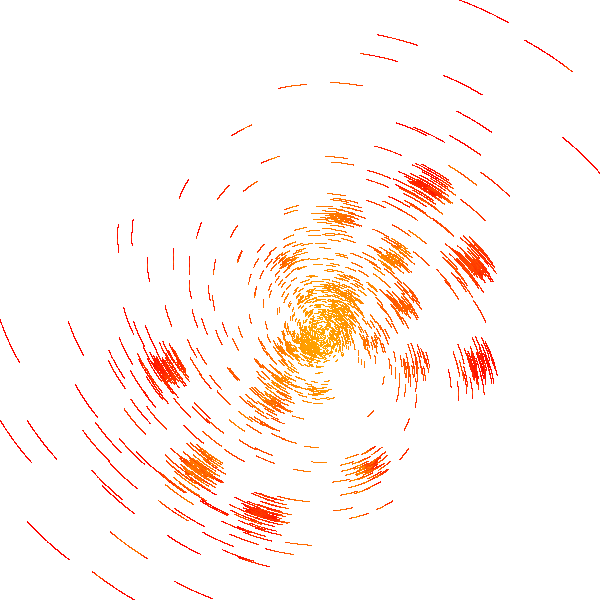

In [11]:

# Extract UV coordinates and create an expression for the intensity of the weighted data
u = combined.UVW.data[:, 0]
v = combined.UVW.data[:, 1]
intensity = da.absolute(
  # Visibility data
  combined.DATA.data[:, :, 0]
  # Visibility weights
  * combined.WEIGHT_SPECTRUM.data[:, :, 0]
  # Bad data mask
  * (combined.FLAG.data[:, :, 0] != 0)
)
render_ds = xarray.Dataset({
  "u": (("row",), u),
  "v": (("row",), v),
  "intensity": (("row", "chan"), intensity),
})

df = render_ds.to_dask_dataframe(dim_order=("row", "chan"))

with ProgressBar():
  canvas = datashader.Canvas()
  points = canvas.points(df, "u", "v", agg=datashader.mean("intensity"))
  plot = transfer_functions.shade(points, cmap=["red", "orange"])

plot

The plot shows how the visibility data is distributed in the [frequency domain](https://en.wikipedia.org/wiki/Frequency_domain) on a 2D UV grid. An interesting feature of this distribution is that each baseline forms *tracks* in the UV plane caused by the rotation of the Earth as time increases.

Low frequency data produced by short baselines is clustered in the centre of the grid, while high frequency data is situated towards the edges of the image. This plot shows that that there are more shorter baselines than longer baselines and this aligns with the fact that MeerKAT is ["core-heavy"](https://skaafrica.atlassian.net/wiki/spaces/ESDKB/pages/277315585/MeerKAT+specifications#Array-layout) in that 70% of the antenna lie within 1km of each other.

Short baselines (low frequencies) contribute to the general structures within a image, while longer baselines (high frequencies) contribute to the fine details. Here's the [ESO137-006](https://www.sarao.ac.za/media-releases/astronomers-stumble-upon-unexpected-features-in-a-distant-galaxy-using-meerkat-data/) image:

![ESO137-006](https://www.sarao.ac.za/wp-content/uploads/2020/04/Collimated-synchatron-threads-low-res.jpg)

Thus, as more time is spent on target, more data is collected and coverage of the UV plane is increased, contributing to the final fidelity of an image created from this data. This loosely corresponds to the concept of exposure in photography. To see the final UV coverage, at the cost of downloading the entire dataset, try setting `nrow_blocks=-1` to plot all the data.

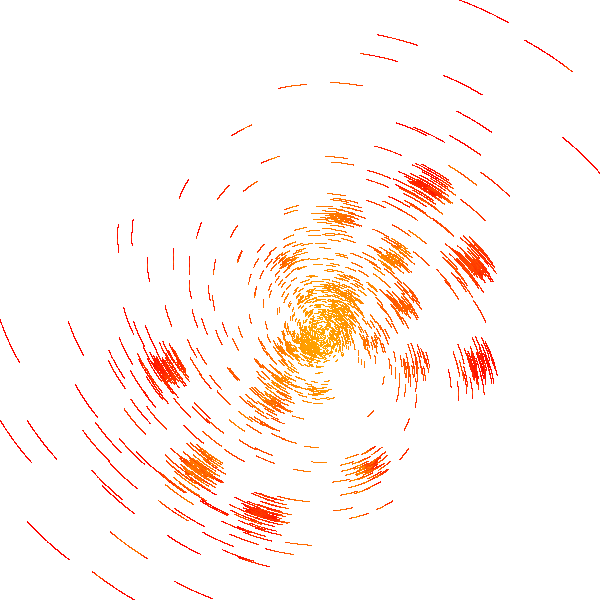

In [12]:
plot

<!-- DATA PROVIDER INSTRUCTIONS
This section is less prescriptive / freeform than previous sections. The goal here is to show an opinionated example of answering a question using your data. The scale of your dataset may preclude a full example, and so feel free to limit the scope of this example (e.g. work on a subset of data). Users should be able to replicate your example in this notebook, and get a sense of how they would scale up.

A "toy" example is better than no example.

Ideally, your example would:
1. Transmit some of your domain & dataset experience to the reader, drawing on your own work as much as possible
2. Provide a jumping off point for users to extend your work, and do novel work of their own.

DATA PROVIDER INSTRUCTIONS 

### Q: What is one question that you have answered using these data? Can you show us how you came to that answer?
-->

### Multiple Collimated Synchrotron Threads (CST) detected outside the lobes of a radio galaxy

With these more sensitive MeerKAT observations new features have been revealed in the form of [multiple collimated
synchrotron threads](https://www.aanda.org/articles/aa/abs/2020/04/aa37800-20/aa37800-20.html) (or CST)
connecting the lobes of the radio galaxy. It is worth nothing that examples of filamentary
structures associated to radio galaxies are well-known in the literature. However, these filaments are usually observed 
inside the radio lobes (see for example the notable cases of Fornax A and Cygnus A
(Maccagni et al. 2020, Perley et al.1984) and the tails of radio galaxies
(see e.g. NGC 1265, 3C 129, and NGC 326; Sijbring & de Bruyn 1998, Lane et al. 2002, Hardcastle et al. 2019)).

The CST detected in ESO 137-006 are different in that they are observed outside the main body of the radio galaxy and connecting
(at least in projection) the two radio lobes. 

<!-- DATA PROVIDER INSTRUCTIONS
This section is, like the previous one, intended to be freeform / non-prescriptive. The goal here is to provide a challenge to the community to do something novel with your dataset. That can either be novel in terms of the task, or novel in terms of methodological or computational approach.

Another way to consider this section, is as a wishlist. If you were less constrained by time, cost, skill, etc., what would you like to see achieved using these data? 

The challenge should, however, be somewhat realistic. A challenge that assumes e.g. original data collection, is likely to go unanswered.
DATA PROVIDER INSTRUCTIONS -->

### Challenge: Distributed imaging of Radio Astronomy data.

Imaging visibility data involves:

1. Gridding visibility onto a square UV grid via [convolutional gridding](https://en.wikipedia.org/wiki/Convolution). The above visualisation gives an impression of what this process involves.
2. Fast Fourier Transforming the gridded data to convert it from the frequency to the image domain.
3. Applying [deconvolution](https://en.wikipedia.org/wiki/Deconvolution) to account for the incomplete sampling of the UV domain.

While gridding and degridding are embarrasingly parallel, parallel deconvolution requires communication between nodes, which limits the parallelism by a straightforward application of [Amdahl's Law](https://en.wikipedia.org/wiki/Amdahl%27s_law). Specialised hardware is probably required to make this tractable for future and upcoming radio telescopes such as the SKA. The [pfb-imaging paper](https://www.sciencedirect.com/science/article/pii/S2213133725000691) explains why this is non-trivial and this dataset serves as a useful test-bed for working towards this goal
